# Practica 04: Analisis de datos exploratorio de python y Jypiter notebook en dataset de productos de amazon store

**Programa de estudios** Ingenieria de entornos virtuales y negocios digitales \
**Asignatura:** Analitica de datos digitales y negocios \
**Docente:** M.T.I. Marco A. Ramirez Hernández \
**Periodo:** Mayo-Agosto 2026 

### Unidad 2: Preparación de datos 

**Nombre del estudiante:** Samantha Salazar Fernández \
**Matricula:** 230004 \
**Grado y grpo:** 9A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)</h1>
<p style="color: #FFD700; text-align: center; font-size: 1.1em; margin-top: 10px;">Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos</p>
</div>

## Tabla de contenido 
|# | Sección | Descripcion |
|---|---|---|
|1|[Instalaciones & Carga de datos](#s1)|Librerias, cargas del cvs, primeros comandos de estructuras|
|2|[Diccionario de datos](#s2)|Explicacion de contenido de columnas y calcular el % porcentaje de datos|
|3|[Limpieza de datos](#s3)|Aplicaci+on de metdos basicos de limpieza (eliminacion de duplicados, agrupació y datos nulos)|
| 4 | [Ingenieria de caracteristicas (Feauturing Engineering)](#s4) | Distribuciones, outliers y pruebas de normalidad |
| 5 | [Análisis Univariado](#s5) | Categorías principales y análisis de precios por categoría |
| 6 | [Análisis por Categoría](#s6) | Patrones de stock y relación con el precio |
| 7 | [Análisis de Disponibilidad](#s7) | Matriz de correlación, scatter plots y relaciones entre variables |
| 8 | [Análisis de Correlación y Bivariado](#s8) | ANOVA, Kruskal-Wallis y correlación de Spearman |
| 9 | [Pruebas de Hipótesis Estadísticas](#s9) | Definición de features, target y split de datos |
| 10 | [Predicción del precio del producto (escala logarítmica)](#s10) | Comparación de modelos y métricas de evaluación |
| 11 | [Marco de Selección de Modelos](#s11) | Entrenamiento y evaluación de 5 modelos predictivos |
| 12 | [Modelos de Regresión — Predicción del Precio en Amazon](#s12) | Optimización con GridSearchCV del mejor modelo |
| 13 | [Ajuste de Hiperparámetros](#s13) | Resultados finales e importancia de variables |
| 14 | [Comparación y Selección de Modelos](#s14) | Insights de negocio y recomendaciones finales |
| 15 | [Hallazgos Clave y Reporte de Negocio](#s15) | Insights de negocio y recomendaciones finales |
| 16 | [Conclusiones](#s1) | Finalidad del reporte |

## 1. Instalaciones & Carga de Datos 🔌 <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Dataset:</b> Amazon India Listas de Prductos - 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y diponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [67]:
# =================================
# Section 1 -Setup & Data loading 
# =================================
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as pit
import matplotlib.ticker as sticker
import seaborn as sns 
import warnings 


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro


from scipy.stats import kruskal, mannwhitneyu, spearmanr
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'Pandas : {pd.__version__}')
print(f'Numpy : {np.__version__}')
print(f'Todas las librerias cargaron con exito!')

# ============================================================
# SECTION 1B — Additional ML Imports
# ============================================================

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Optional: XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost disponible.')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️ XGBoost no instalado. Se utilizará Gradient Boosting.')


## 13 seccion importaciones 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 14 seccion 
from scipy import stats

Pandas : 2.3.3
Numpy : 2.3.5
Todas las librerias cargaron con exito!
⚠️ XGBoost no instalado. Se utilizará Gradient Boosting.


In [3]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f'Shape : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape : (1444, 17)
Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de datos de dataframe <a id='s2'></a>

In [4]:
col_info = {
    'url': 'URL del producto en Amazon.in',
    'asin': 'Número estandarizado de identificación por Amazon (ID único)',
    'name': 'Nombre o título del producto',
    'overview': 'Breve reseña del producto (mayoría vacío [])',
    'price': 'Precio como string (ej. "1,600.00")',
    'currency': 'Código de divisa (todas en INR)',
    'availability': 'Texto del estado del stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URL de la imagen principal',
    'description': 'Descripción detallada y completa',
    'specification': 'Especificaciones técnicas',
    'primary_category': 'Categoría principal',
    'category_1': 'Categoría de nivel 1',
    'category_2': 'Categoría de nivel 2',
    'category_3': 'Categoría de nivel 3',
    'breadcrumbs': 'Ruta de navegación de categorías'
}

print('Diccionario de columnas')
print('-' * 90)

for col, desc in col_info.items():
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100

        print(
            f'{col:20s}| '
            f'{desc[:45]:45s}| '
            f'Missing: {missing_pct:.0f}%'
        )
    else:
        print(
            f'{col:20s}| '
            f'{desc[:45]:45s}| '
            f'NO EXISTE EN EL DATAFRAME'
        )

Diccionario de columnas
------------------------------------------------------------------------------------------
url                 | URL del producto en Amazon.in                | NO EXISTE EN EL DATAFRAME
asin                | Número estandarizado de identificación por Am| Missing: 0%
name                | Nombre o título del producto                 | Missing: 0%
overview            | Breve reseña del producto (mayoría vacío []) | Missing: 0%
price               | Precio como string (ej. "1,600.00")          | Missing: 24%
currency            | Código de divisa (todas en INR)              | Missing: 24%
availability        | Texto del estado del stock (Inventario)      | Missing: 33%
brand               | Nombre de la Marca/Autor                     | Missing: 1%
about_item          | Detalles/Especificaciones (mayoría faltante) | Missing: 92%
img_source          | URL de la imagen principal                   | Missing: 0%
description         | Descripción detallada y completa   

## 3.Limpieza de datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# Parse price
def clean_price(p):
    if pd.isna(p):
        return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# Standardise availability
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'
    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'
    if 'unavailable' in a:
        return 'Unavailable'
    if '1 to 3' in a:
        return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:
        return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# Text length features
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# Duplicate check
dupes = df.duplicated(subset='asin').sum()

print(f'Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'Duplicate ASINs: {dupes}')
print(f'Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

Price parsed: 1,100 / 1,444 products
Duplicate ASINs: 5
Availability categories: {'In Stock': 611, 'Unknown': 478, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


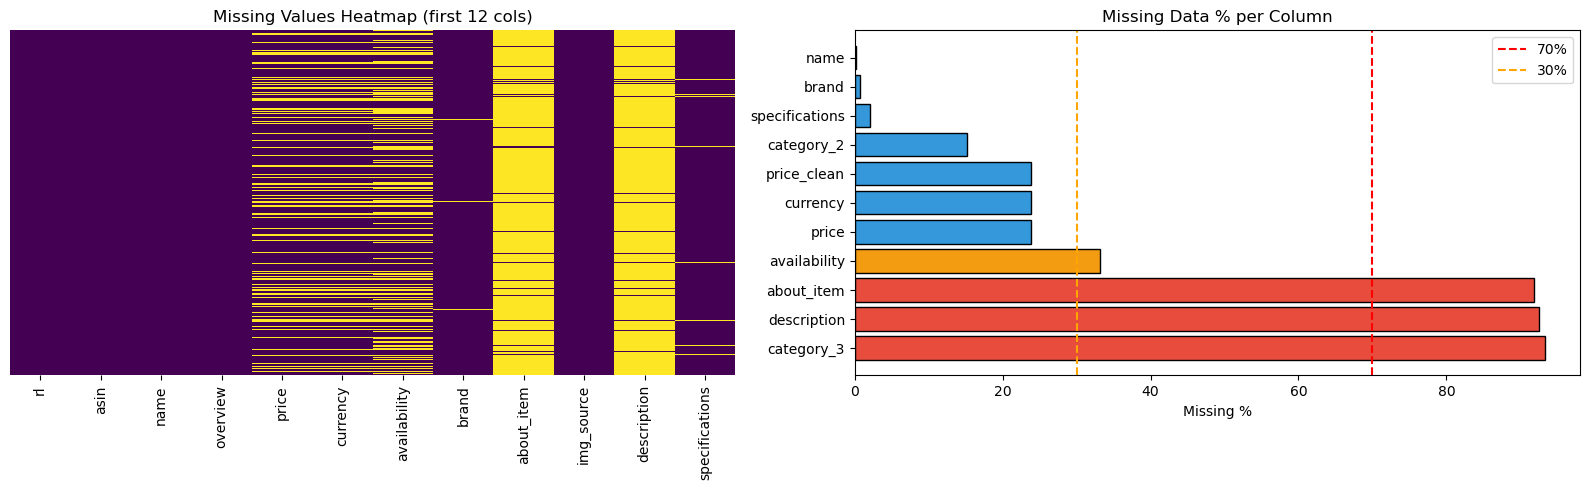

                Missing Count  Missing Pct
category_3               1348         93.4
description              1336         92.5
about_item               1325         91.8
availability              478         33.1
price                     344         23.8
currency                  344         23.8
price_clean               344         23.8
category_2                220         15.2
specifications             29          2.0
brand                      10          0.7
name                        1          0.1


In [6]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

# Crear figura
fig, axes = pit.subplots(1, 2, figsize=(16, 5))

# Heatmap de valores faltantes
sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title('Missing Values Heatmap (first 12 cols)')

# Filtrar columnas con valores faltantes
mv = missing[missing['Missing Pct'] > 0]

# Colores según porcentaje de faltantes
colors_mv = [
    '#e74c3c' if v > 70
    else '#F39c12' if v > 30
    else '#3498db'
    for v in mv['Missing Pct']
]

# Gráfico de barras
axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')

axes[1].legend()
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

pit.tight_layout()
pit.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feauturing Engineering)

<div style="background: #f0fff0; padding: 12px; border-left:4px solid #27ae68; border-radius: 5px; color: #0066cc;">
<b> Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que tambiénconsidera la ubicación, la antigüedad y
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [7]:
# ============================================================
# SECTION 4 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        286
3_mid        320
4_premium    262
5_luxury     127
Unknown      344


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariado

El análisis univariado estudia una sola variable a la vez para comprender su comportamiento y características principales.

In [8]:
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')

def price_tier(p):
    if pd.isna(p):
        return 'Unknown'
    elif p < 300:
        return '1_budget'
    elif p < 800:
        return '2_low'
    elif p < 1500:
        return '3_mid'
    elif p < 3000:
        return '4_premium'
    else:
        return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

print("✔ price_tier creada correctamente")
print(df['price_tier'].value_counts().sort_index())

✔ price_tier creada correctamente
price_tier
1_budget     105
2_low        286
3_mid        320
4_premium    262
5_luxury     127
Unknown      344
Name: count, dtype: int64


In [9]:
print('price_tier' in df.columns)

True


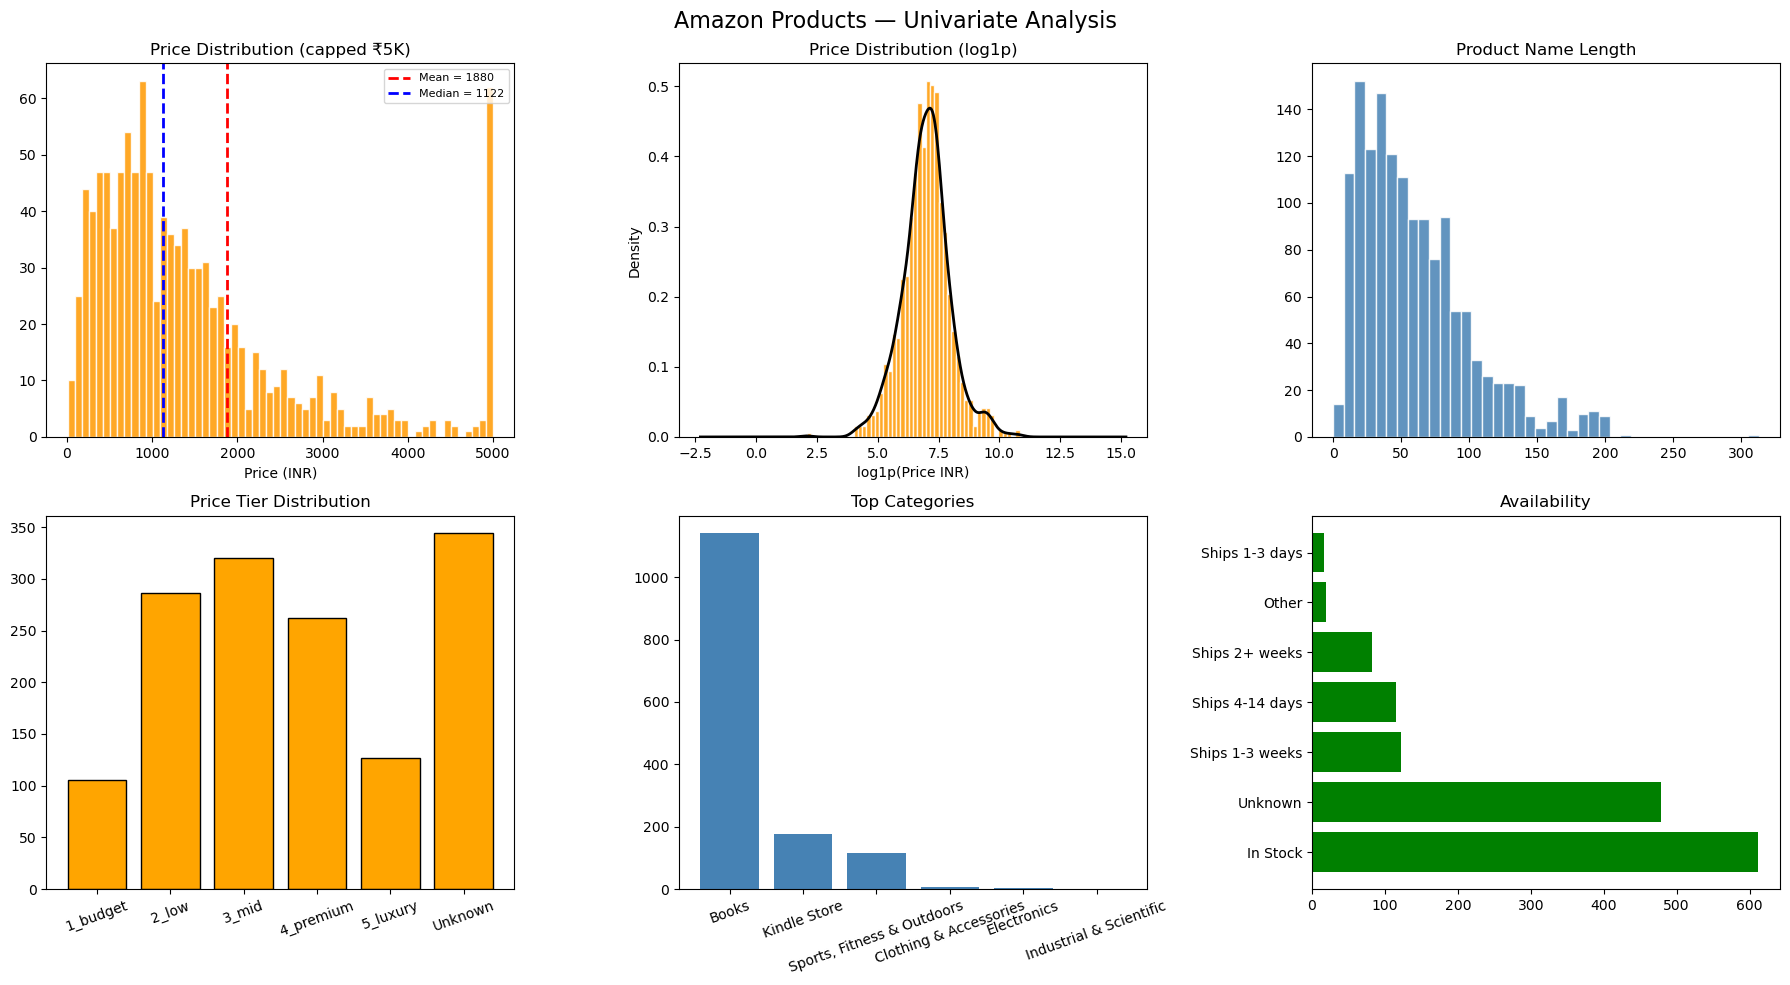

Shapiro-Wilk: stat=0.9872, p=0.000230
→ Log price NOT normal
count     1093.00
mean      1879.84
std       3332.37
min          7.00
25%        613.06
50%       1122.00
75%       1850.00
max      50555.00
Name: price_clean, dtype: float64


In [10]:
# ============================================================
# SECTION 5 — Univariate Analysis (CORREGIDO)
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import shapiro

# ── Asegurar que price_clean sea numérico ───────────────────
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')

# ── Subset seguro ────────────────────────────────────────────
df_priced = df[
    df['price_clean'].notna() &
    (df['price_clean'] > 0)
].copy()

# ── Asegurar log_price exista ───────────────────────────────
df_priced['log_price'] = np.log1p(df_priced['price_clean'])

# ── Crear figura ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ============================================================
# 1. Price distribution (raw)
# ============================================================
axes[0, 0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

axes[0, 0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f"Mean = {df_priced['price_clean'].mean():.0f}"
)

axes[0, 0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f"Median = {df_priced['price_clean'].median():.0f}"
)

axes[0, 0].set_title('Price Distribution (capped ₹5K)')
axes[0, 0].set_xlabel('Price (INR)')
axes[0, 0].legend(fontsize=8)

# ============================================================
# 2. Log price distribution
# ============================================================
axes[0, 1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(
    ax=axes[0, 1],
    color='black',
    lw=2
)

axes[0, 1].set_title('Price Distribution (log1p)')
axes[0, 1].set_xlabel('log1p(Price INR)')

# ============================================================
# 3. Name length (SAFE CHECK)
# ============================================================
if 'name_length' in df.columns:
    axes[0, 2].hist(
        df['name_length'].dropna(),
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[0, 2].set_title('Product Name Length')
else:
    axes[0, 2].text(0.5, 0.5, 'name_length NOT FOUND', ha='center')

# ============================================================
# 4. Price tier (FIX PRINCIPAL)
# ============================================================
if 'price_tier' in df.columns:
    tier_counts = df['price_tier'].value_counts().sort_index()

    axes[1, 0].bar(
        tier_counts.index.astype(str),
        tier_counts.values,
        color='orange',
        edgecolor='black'
    )

    axes[1, 0].set_title('Price Tier Distribution')
    axes[1, 0].tick_params(axis='x', rotation=20)

else:
    axes[1, 0].text(0.5, 0.5, 'price_tier NOT FOUND', ha='center')

# ============================================================
# 5. Category (SAFE)
# ============================================================
if 'primary_category' in df.columns:
    cat_counts = df['primary_category'].value_counts().head(10)

    axes[1, 1].bar(
        cat_counts.index.astype(str),
        cat_counts.values,
        color='steelblue'
    )

    axes[1, 1].set_title('Top Categories')
    axes[1, 1].tick_params(axis='x', rotation=20)
else:
    axes[1, 1].text(0.5, 0.5, 'primary_category NOT FOUND', ha='center')

# ============================================================
# 6. Availability (SAFE)
# ============================================================
if 'avail_clean' in df.columns:
    avail_counts = df['avail_clean'].value_counts()

    axes[1, 2].barh(
        avail_counts.index.astype(str),
        avail_counts.values,
        color='green'
    )

    axes[1, 2].set_title('Availability')
else:
    axes[1, 2].text(0.5, 0.5, 'avail_clean NOT FOUND', ha='center')

# ============================================================
# Layout
# ============================================================
plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================
# Normality test (SAFE)
# ============================================================
sample = df_priced['log_price'].dropna()

if len(sample) > 3:
    sample = sample.sample(min(500, len(sample)), random_state=42)

    stat, p = shapiro(sample)

    print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.6f}")

    if p > 0.05:
        print("→ Log price ~ normal")
    else:
        print("→ Log price NOT normal")

# ============================================================
# Stats
# ============================================================
print(df_priced['price_clean'].describe().round(2))

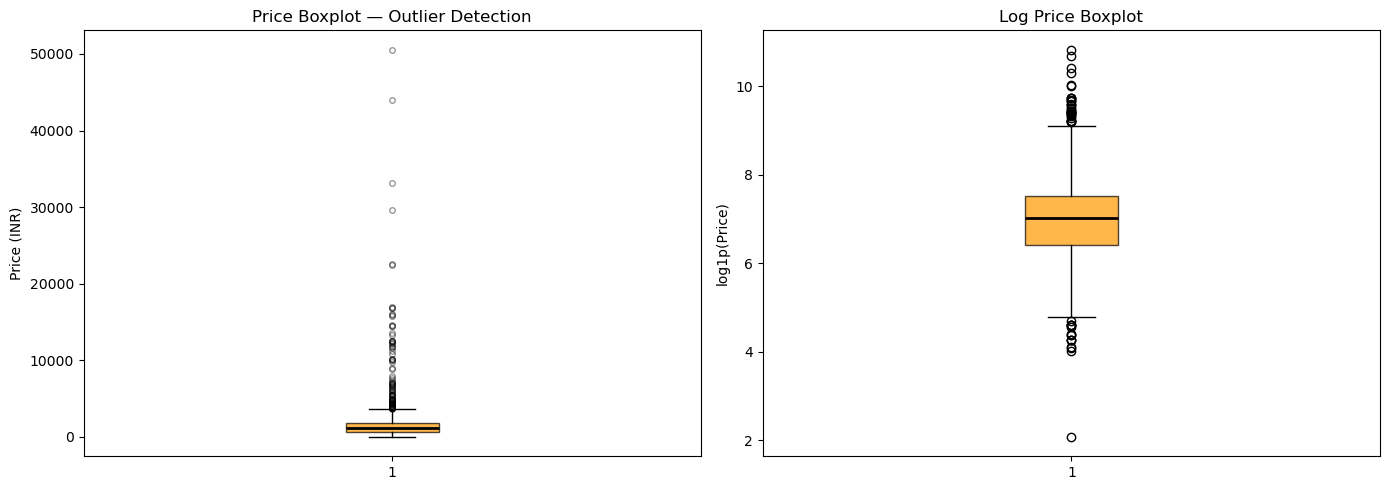

IQR method outliers: 94 (8.6%)
Price range (non-outlier): ₹-1242 – ₹3705

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [12]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis por Categoría

Comparar los precios entre categorías y subcategorías para identificar cuáles contienen los productos más caros, cuáles predominan en el catálogo y 
dónde se concentra el mayor valor económico.

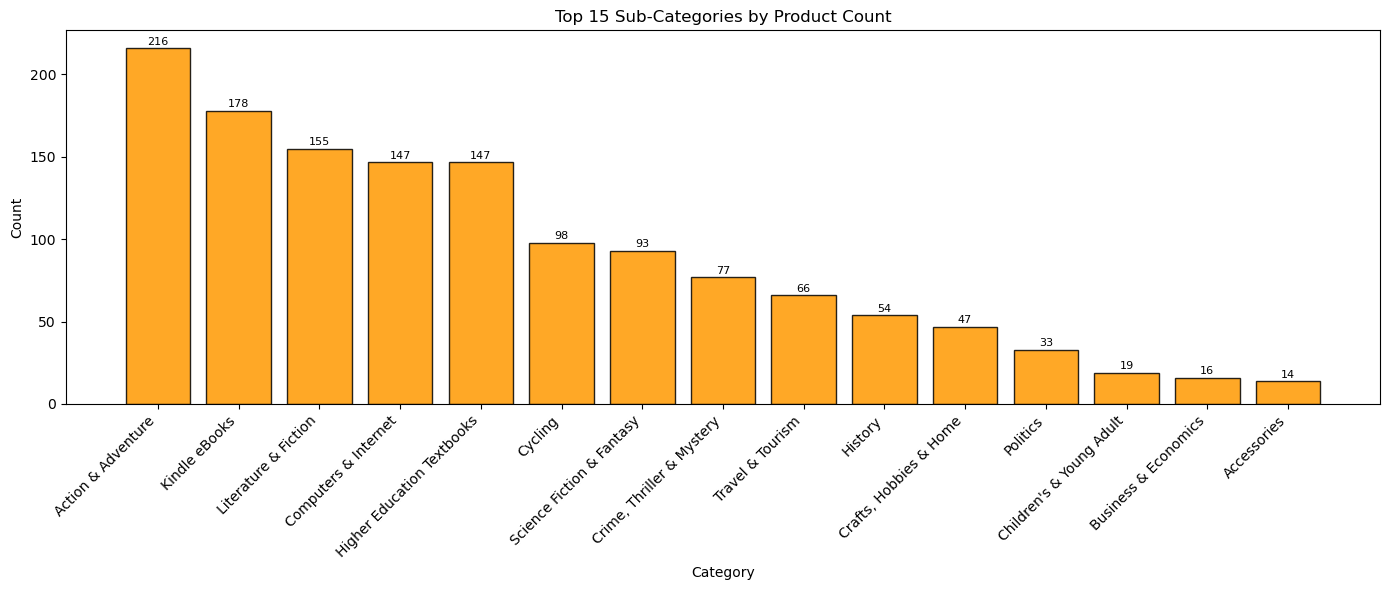

In [20]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

C:\Users\PC-08\AppData\Local\Temp\ipykernel_4936\1881029386.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


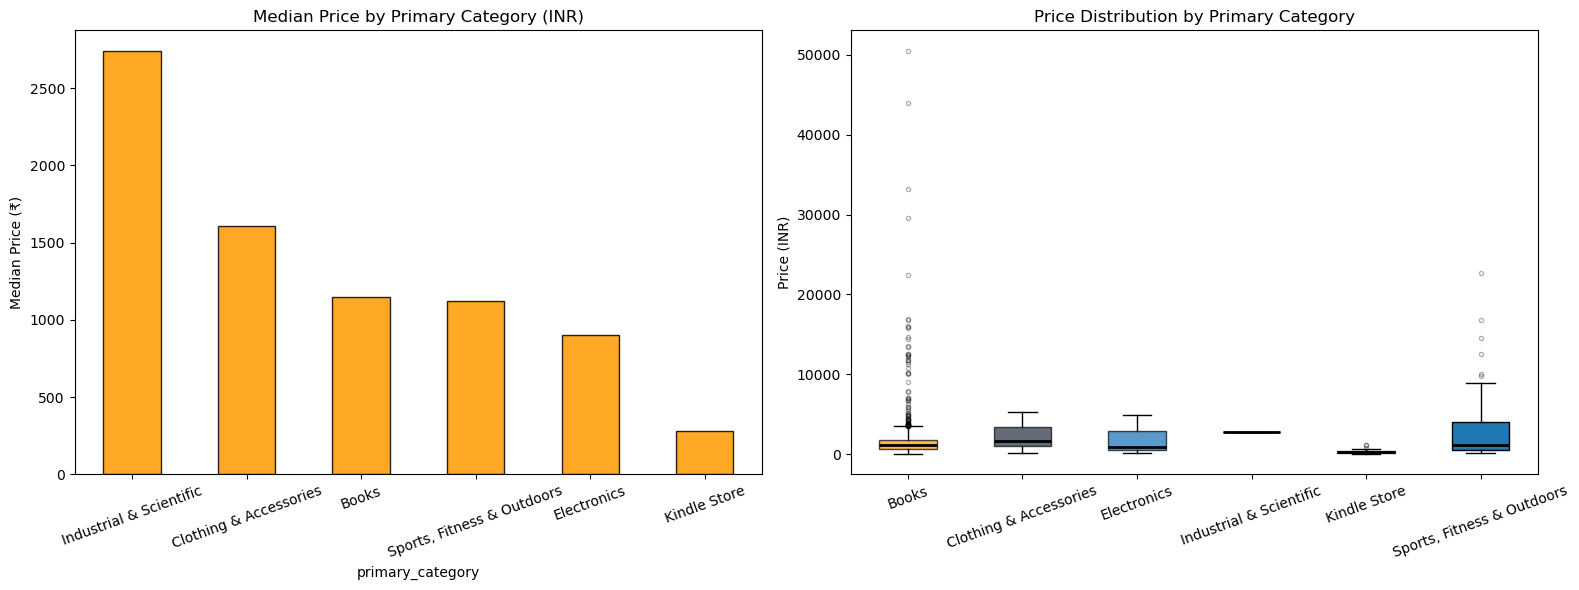

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1824.5  1145.0    960
Clothing & Accessories      2249.2  1606.5      6
Electronics                 1995.7   899.0      3
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [21]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())

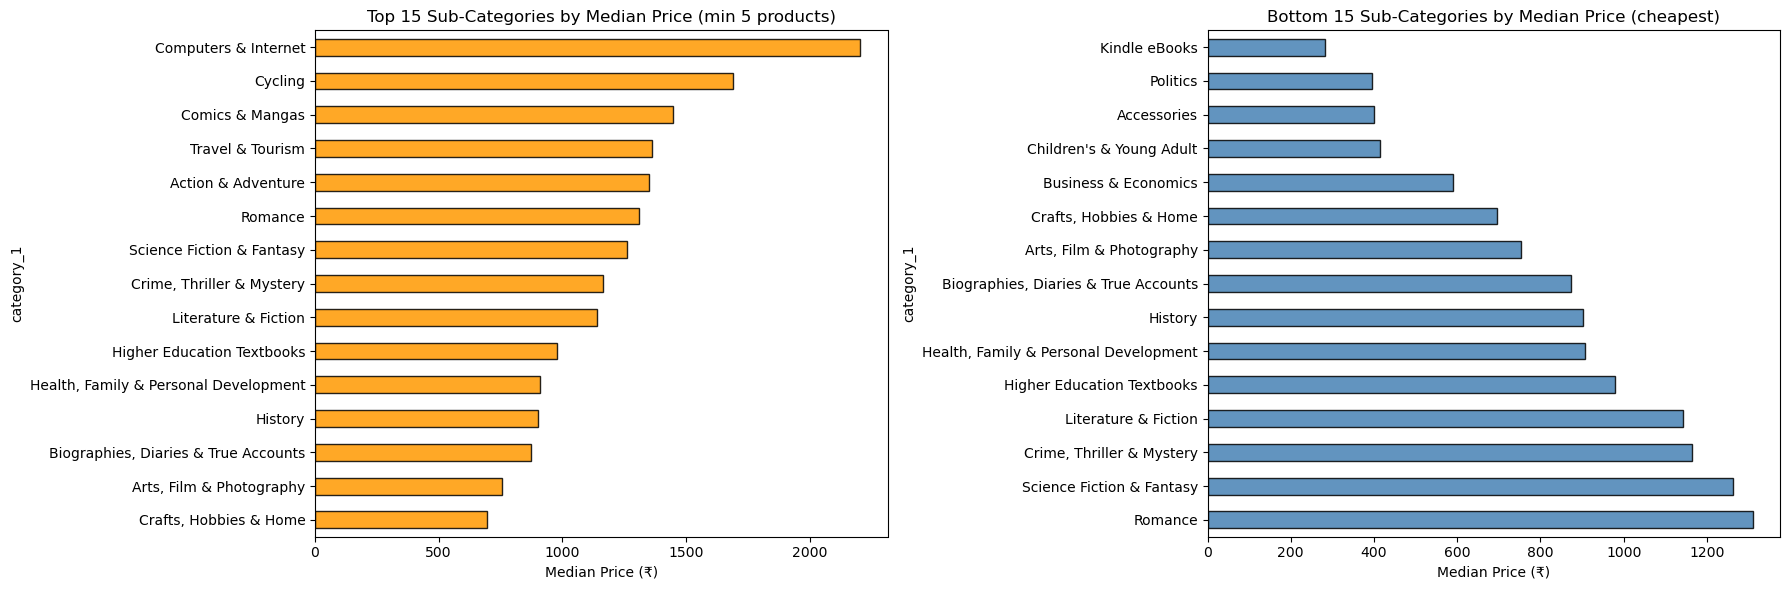

In [13]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.Análisis de Disponibilidad

In [ ]:
Examinar cómo el estado de disponibilidad (In Stock, Out of Stock, etc.) se relaciona con el precio de los productos y 
determinar si los artículos premium tienen una mayor probabilidad de estar agotados.

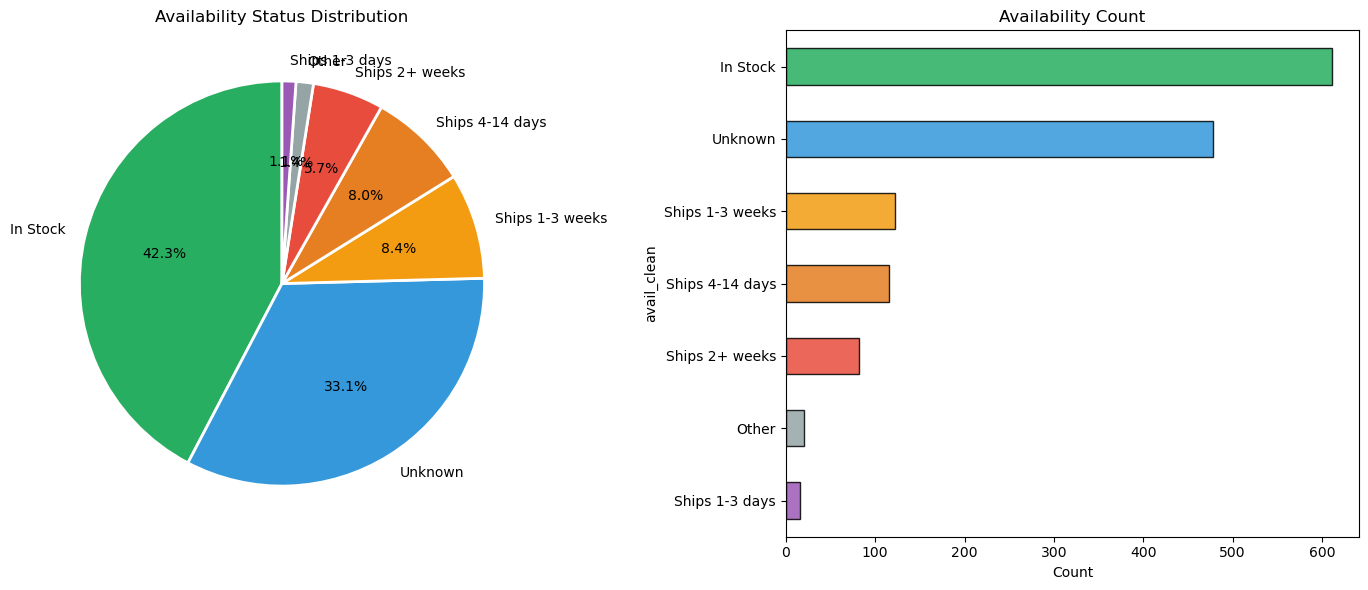

In [14]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


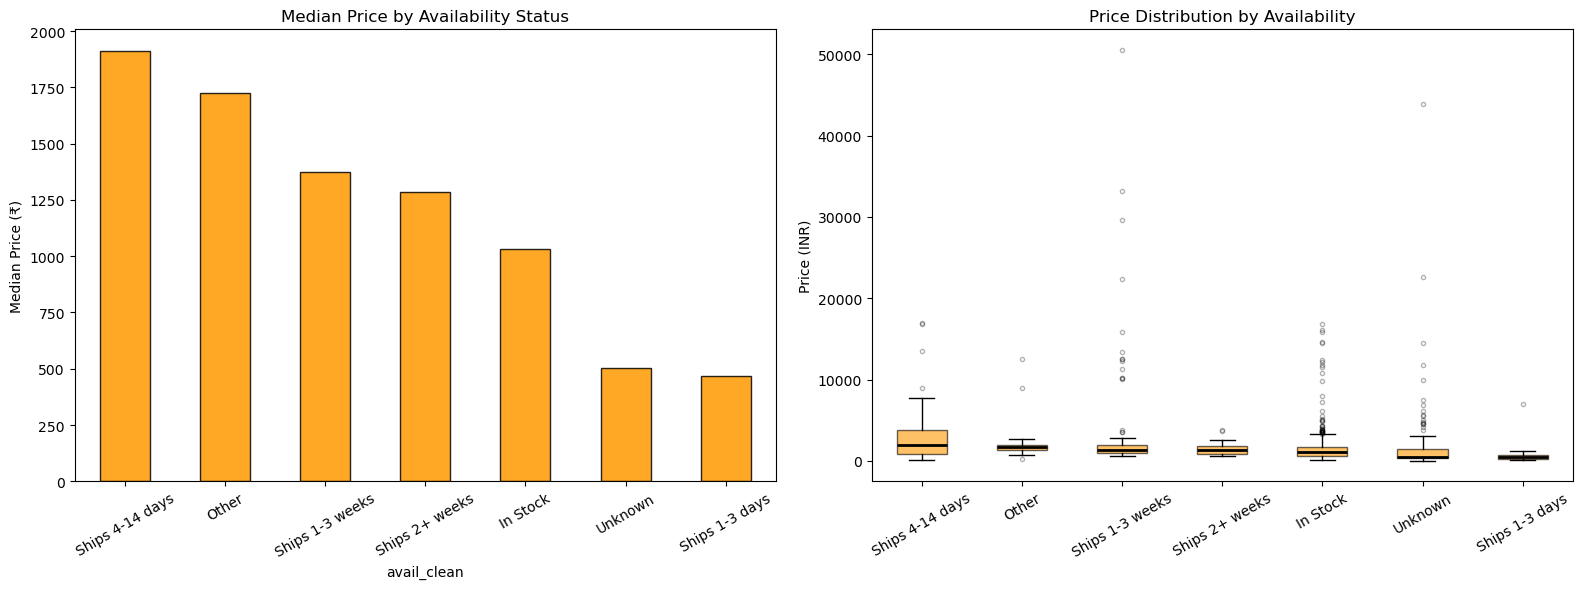

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1376.0  3210.8    122
Ships 2+ weeks   1284.5  1403.9     82
In Stock         1030.0  1493.1    603
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [15]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8.Análisis de Correlación y Bivariado

Analizar la relación entre dos variables para identificar cuáles características están más asociadas con el precio del 
producto y determinar qué factores pueden ayudar a predecirlo.

In [31]:
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
df['log_price'] = np.log1p(df['price_clean'])

print("✔ log_price creado")

✔ log_price creado


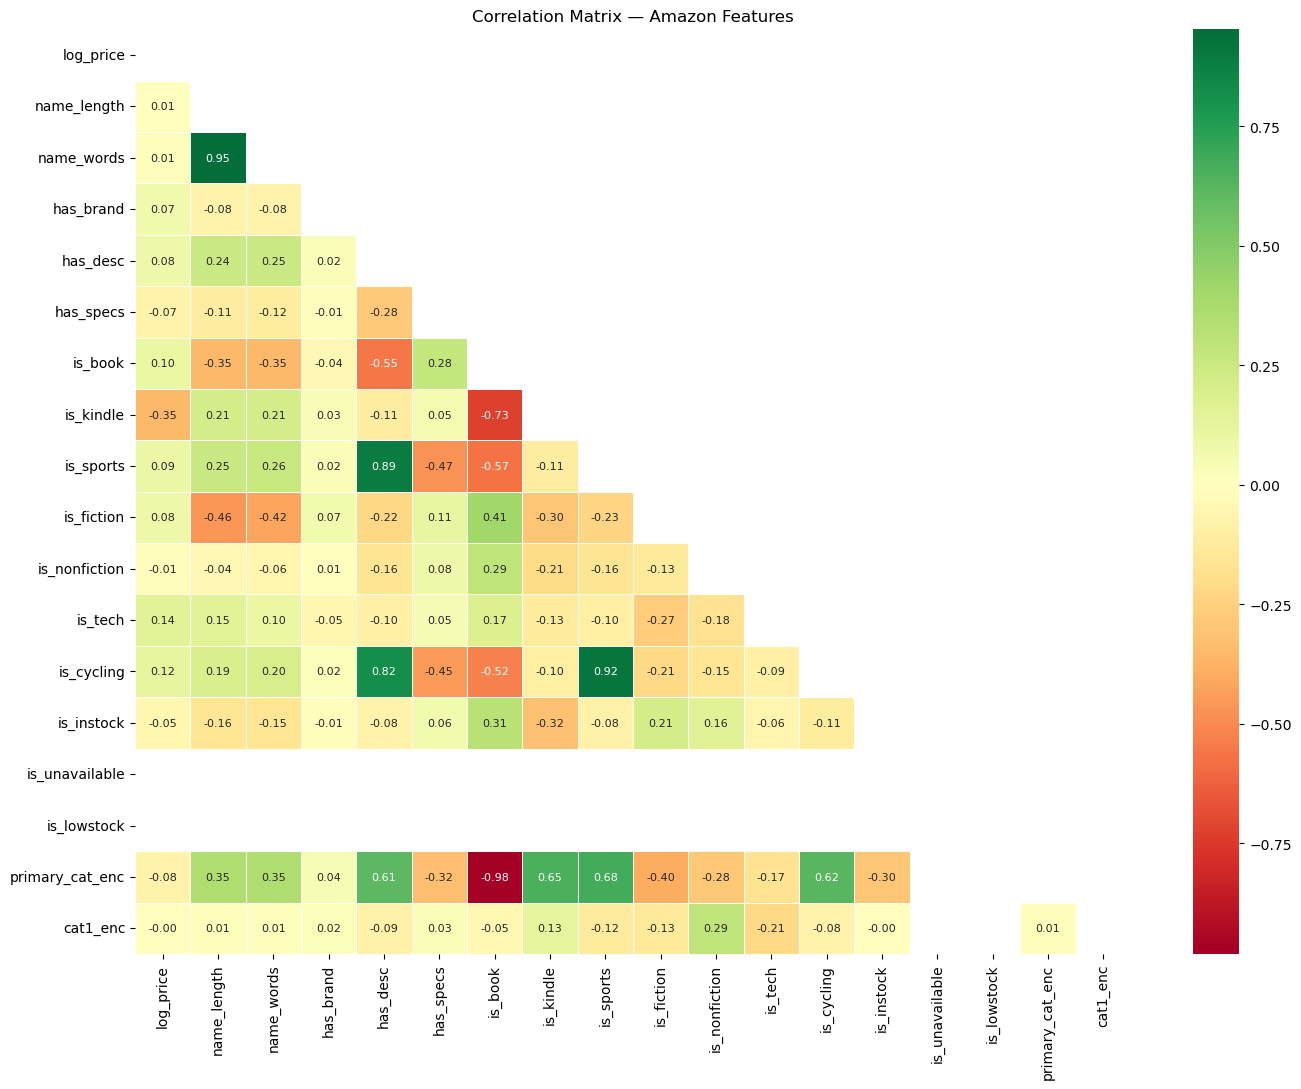


Top correlations with log_price:
is_tech            0.144930
is_cycling         0.120708
is_book            0.103122
is_sports          0.091591
is_fiction         0.083842
has_desc           0.081911
has_brand          0.069553
name_words         0.014808
name_length        0.007530
cat1_enc          -0.004389
is_nonfiction     -0.013824
is_instock        -0.054892
has_specs         -0.069738
primary_cat_enc   -0.076127
is_kindle         -0.351939
is_unavailable          NaN
is_lowstock             NaN


In [32]:
corr_cols = [
    'log_price','name_length','name_words','has_brand','has_desc',
    'has_specs','is_book','is_kindle','is_sports','is_fiction',
    'is_nonfiction','is_tech','is_cycling','is_instock',
    'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc'
]

# Solo columnas que EXISTEN
valid_cols = [c for c in corr_cols if c in df.columns]

corr = df[valid_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

plt.title('Correlation Matrix — Amazon Features')
plt.tight_layout()
plt.show()

# Solo si log_price existe
if 'log_price' in corr.columns:
    print('\nTop correlations with log_price:')
    print(
        corr['log_price']
        .drop('log_price')
        .sort_values(ascending=False)
        .to_string()
    )
else:
    print("⚠ log_price no está en el dataset")

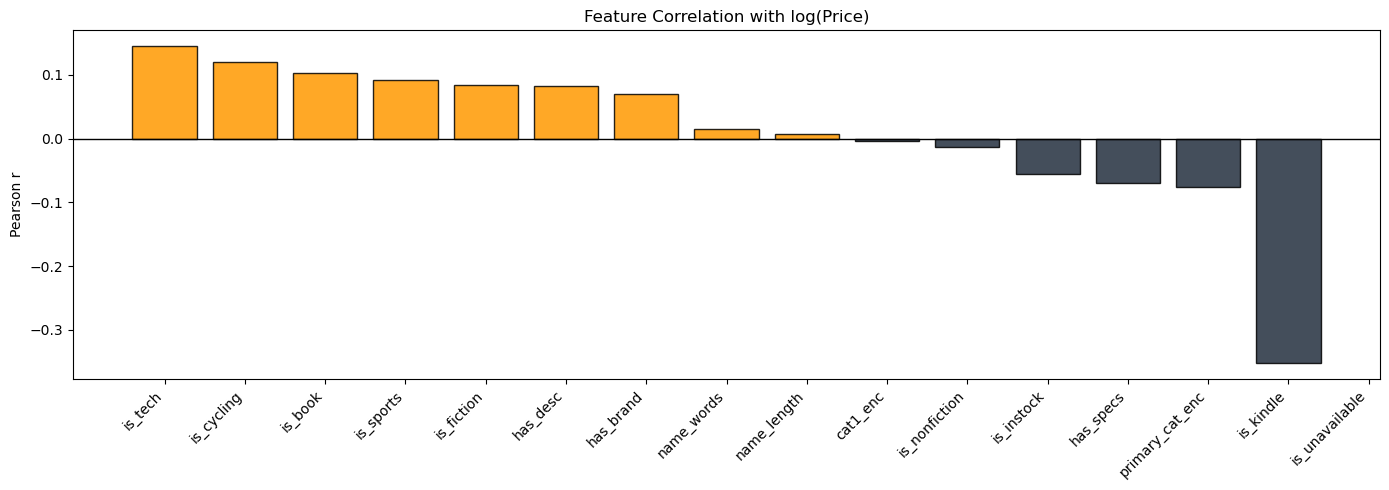

In [33]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

le_cat = LabelEncoder()

df['primary_cat_enc'] = le_cat.fit_transform(
    df['primary_category'].fillna('Unknown')
)

In [37]:
df_priced = df[
    df['price_clean'].notna() &
    (df['price_clean'] > 0)
].copy()

In [38]:
df_priced['log_price'] = np.log1p(df_priced['price_clean'])

In [39]:
df_priced['primary_cat_enc'] = df['primary_cat_enc']

C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\2849255280.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


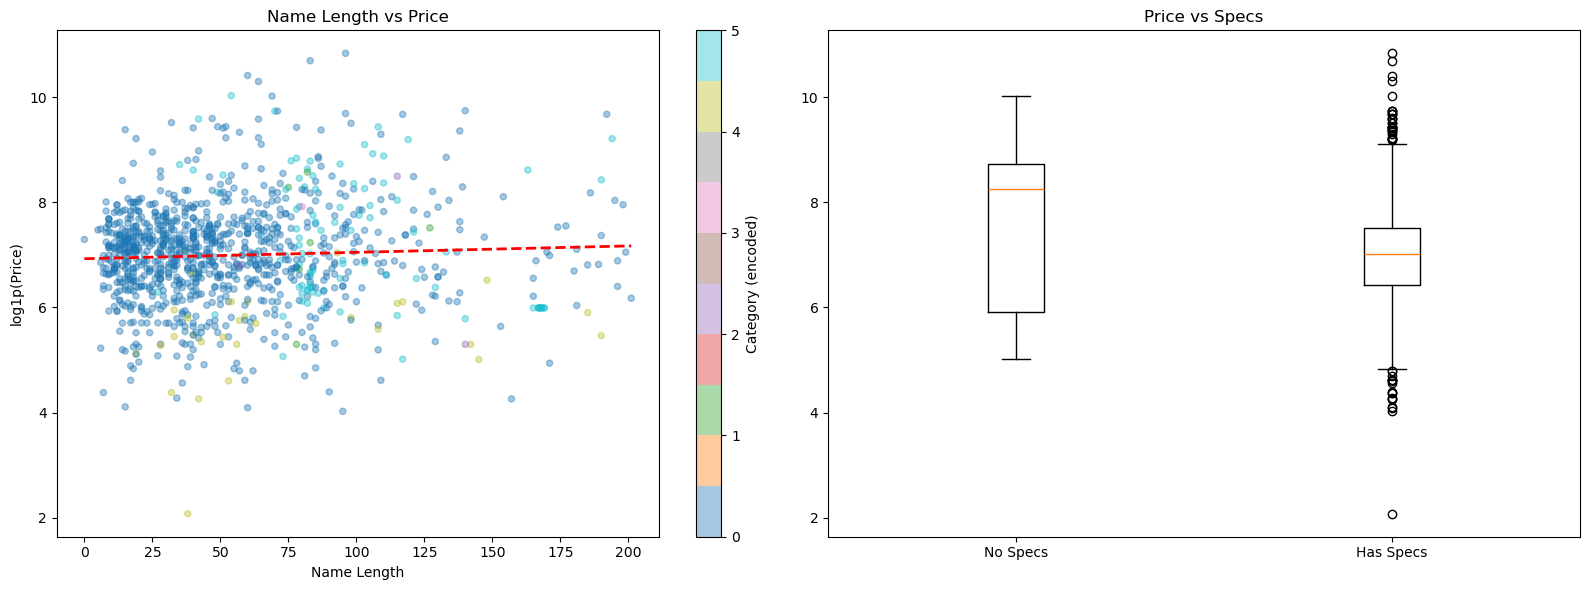

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_priced['log_price'] = np.log1p(df_priced['price_clean'])

# Scatter
sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

plt.colorbar(sc, ax=axes[0], label='Category (encoded)')

m, b = np.polyfit(
    df_priced['name_length'],
    df_priced['log_price'],
    1
)

x = np.linspace(0, df_priced['name_length'].max(), 100)

axes[0].plot(x, m*x + b, 'r--', lw=2)

axes[0].set_xlabel('Name Length')
axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price')

# Boxplot
axes[1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs'] == 0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs'] == 1]['price_clean'])
    ],
    labels=['No Specs', 'Has Specs']
)

axes[1].set_title('Price vs Specs')

plt.tight_layout()
plt.show()

## 9.Pruebas de Hipótesis Estadísticas

Determinar si existen diferencias estadísticamente significativas en los precios entre grupos de productos utilizando pruebas 
no paramétricas, ya que la variable precio presenta una distribución sesgada y no normal.

| H# | Hipótesis | Prueba |
|----|-----------|--------|
| H1 | El precio difiere significativamente entre categorías principales | Kruskal-Wallis |
| H2 | El precio de libros es significativamente menor que el de productos deportivos | Mann-Whitney U |
| H3 | Los productos en stock tienen precios diferentes a los no disponibles | Mann-Whitney U |
| H4 | La longitud del nombre está positivamente correlacionada con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen precios más altos | Mann-Whitney U |

In [49]:
# ============================================================
# SECTION 9 — Hypothesis Testing
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()
    return p

# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Price across Primary Categories — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Books vs Sports Products Price',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Books', 'Sports')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: In-Stock vs Unavailable Price',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'In Stock', 'Unavailable')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Products With vs Without Specifications',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Has Specs', 'No Specs')

H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=960, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.9470, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=960, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40494, p=0.138774
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  In Stock: n=603, median=₹1030
  Unavailable: n=0, median=₹nan
  Mann-Whitney U=nan, p=nan
  RESULT: ❌ FAIL TO REJECT H0.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0354, p=0.241692
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1072, median=₹1118
  No Specs: n=21, median=₹3818
  Mann-Whitney U=9012, p=0.117340
  RESULT: ❌ FAIL TO REJECT H0.



C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\957623606.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')


C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\4087654027.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\4087654027.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\4087654027.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\4087654027.py:4

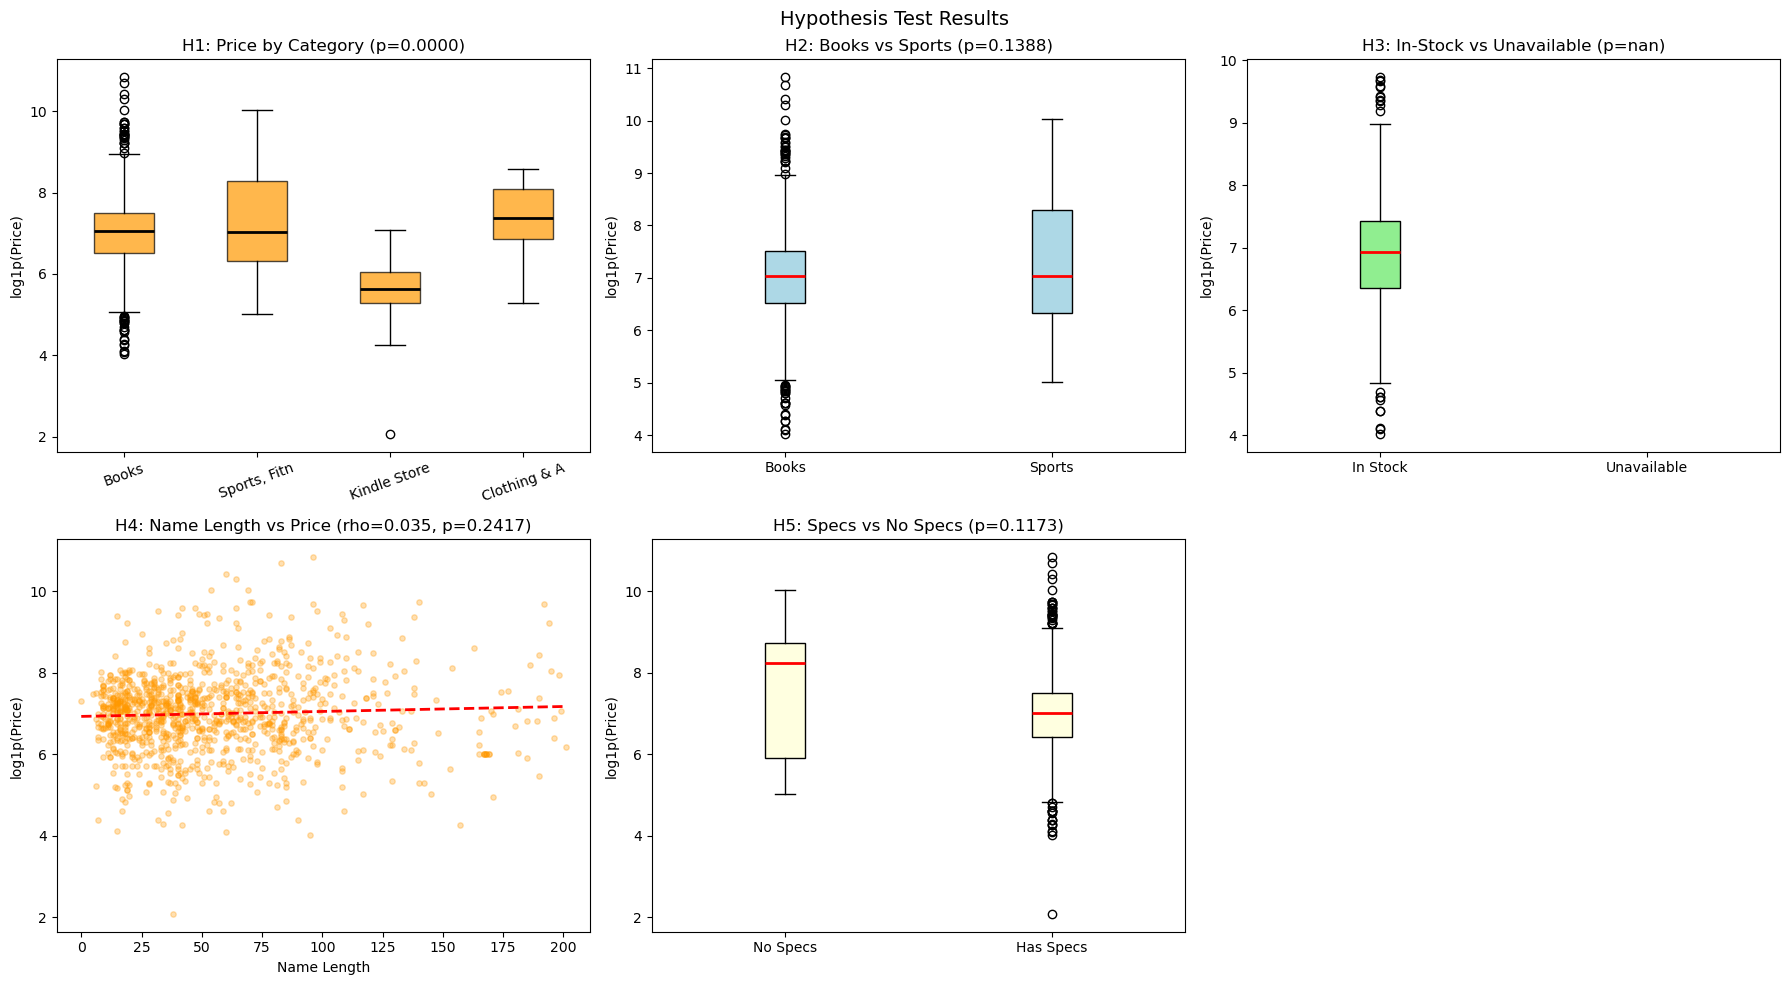

In [50]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Price by Category (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Price)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Books','Sports'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Price)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['In Stock','Unavailable'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Price)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Name Length'); axes[1,0].set_ylabel('log1p(Price)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['No Specs','Has Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Price)')

axes[1,2].set_visible(False)
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout(); plt.show()

## 10.Predicción del precio del producto (escala logarítmica)

Predecir el precio de los productos utilizando variables como la categoría, la longitud del nombre,
la disponibilidad y variables indicadoras de características (feature flags).


✅ Features disponibles: 18 / 18
✅ ML dataset shape : (1093, 20)
✅ Features usados  : 18

Train: 874 | Test: 219


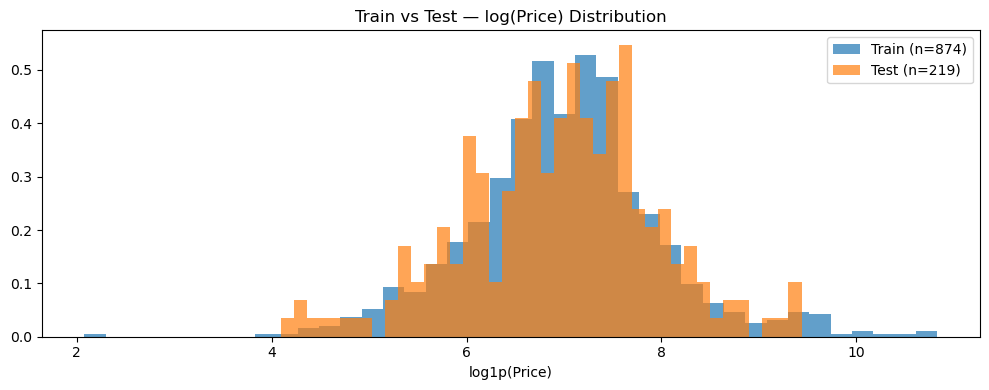

✅ Distribuciones similares — split correcto


In [51]:
# ============================================================
# SECTION 10 — ML Problem Framing (FIXED VERSION)
# ===========================================================

# -----------------------------
# 1. Feature columns (original)
# -----------------------------
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

# -----------------------------
# 2. Safety check: missing cols
# -----------------------------
missing_cols = [col for col in FEATURE_COLS if col not in df_priced.columns]

if len(missing_cols) > 0:
    print("⚠️ Columnas faltantes detectadas:")
    print(missing_cols)

# Solo usar las que sí existen
existing_features = [col for col in FEATURE_COLS if col in df_priced.columns]

print(f"\n✅ Features disponibles: {len(existing_features)} / {len(FEATURE_COLS)}")

# -----------------------------
# 3. Build ML dataset safely
# -----------------------------
df_ml = df_priced[existing_features + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features usados  : {len(existing_features)}')

# -----------------------------
# 4. Split X / y
# -----------------------------
X = df_ml[existing_features]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# -----------------------------
# 5. Scaling
# -----------------------------
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# -----------------------------
# 6. Visualisation
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    alpha=0.7,
    label=f'Train (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    alpha=0.7,
    label=f'Test (n={len(y_test)})',
    density=True
)

ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Distribuciones similares — split correcto')

## 11.Marco de Selección de Modelos

| Modelo | Fortalezas | Debilidades | Mejor Uso |
|---------|------------|-------------|-----------|
| Regresión Lineal | Rápida e interpretable | Asume una relación lineal | Modelo base (Baseline) |
| Regresión Ridge | Maneja la multicolinealidad | Sigue siendo un modelo lineal | Variables altamente correlacionadas |
| Regresión Lasso | Selección automática de variables | Puede eliminar variables útiles | Conjuntos de datos con muchas variables y características dispersas |
| Random Forest | Captura relaciones no lineales y es robusto | Menor interpretabilidad | Patrones complejos |
| XGBoost / GBM | Alta precisión predictiva | Requiere ajuste de hiperparámetros | Datos tabulares |

Métricas de Evaluación

- **MAE (Mean Absolute Error):** Error absoluto medio calculado sobre la escala logarítmica del precio. Valores más bajos indican un mejor desempeño del modelo.

- **RMSE (Root Mean Squared Error):** Raíz del error cuadrático medio. Penaliza más los errores grandes, por lo que valores más bajos representan un mejor ajuste del modelo.

- **R² (Coeficiente de Determinación):** Mide la proporción de la variabilidad del precio explicada por el modelo. Valores más altos indican un mejor desempeño, siendo 1.0 el valor máximo posible.

- **MAE (₹):** Error absoluto medio transformado nuevamente a rupias indias (INR) para facilitar la interpretación desde una perspectiva de negocio. Indica, en promedio, cuántas rupias se equivoca el modelo en sus predicciones.

In [52]:
# ============================================================
# SECTION 11 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


## 12.Modelos de Regresión — Predicción del Precio en Amazon

Entrenar y evaluar cinco modelos de regresión para predecir el precio de los productos de Amazon utilizando las mismas variables de entrada y el mismo conjunto de prueba.dentificar el modelo que ofrece el mejor equilibrio entre precisión predictiva, capacidad de generalización e interpretabilidad para la predicción del precio de los productos.

In [55]:
# ============================================================
# SECTION 12 — Train All Models
# ============================================================
print('=' * 60)
print('TRAINING ALL MODELS')
print('=' * 60)

# ------------------------------------------------------------
# 1. Linear Regression
# ------------------------------------------------------------
lr = LinearRegression()

lr.fit(X_train_s, y_train)

lr_pred = eval_model(
    'Linear Regression',
    y_test,
    lr.predict(X_test_s)
)

# ------------------------------------------------------------
# 2. Ridge Regression
# ------------------------------------------------------------
ridge = Ridge(alpha=10.0)

ridge.fit(X_train_s, y_train)

ridge_pred = eval_model(
    'Ridge Regression',
    y_test,
    ridge.predict(X_test_s)
)

# ------------------------------------------------------------
# 3. Lasso Regression
# ------------------------------------------------------------
lasso = Lasso(
    alpha=0.01,
    max_iter=5000,
    random_state=42
)

lasso.fit(X_train_s, y_train)

lasso_pred = eval_model(
    'Lasso Regression',
    y_test,
    lasso.predict(X_test_s)
)

# ------------------------------------------------------------
# 4. Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = eval_model(
    'Random Forest',
    y_test,
    rf.predict(X_test)
)

# ------------------------------------------------------------
# 5. XGBoost / Gradient Boosting
# ------------------------------------------------------------
if XGB_AVAILABLE:

    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror',
        verbosity=0
    )

    xgb_model.fit(X_train, y_train)

    xgb_pred = eval_model(
        'XGBoost',
        y_test,
        xgb_model.predict(X_test)
    )

else:

    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )

    gbm.fit(X_train, y_train)

    xgb_pred = eval_model(
        'Gradient Boosting',
        y_test,
        gbm.predict(X_test)
    )

print('\n✅ All models trained successfully.')

TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.7057  |  MAE (₹) = ₹1,027
     RMSE (log) = 0.9278  |  R²      = 0.1190
  📊 Ridge Regression:
     MAE (log)  = 0.6974  |  MAE (₹) = ₹1,020
     RMSE (log) = 0.9067  |  R²      = 0.1586
  📊 Lasso Regression:
     MAE (log)  = 0.6983  |  MAE (₹) = ₹1,019
     RMSE (log) = 0.9074  |  R²      = 0.1573
  📊 Random Forest:
     MAE (log)  = 0.6367  |  MAE (₹) = ₹936
     RMSE (log) = 0.8468  |  R²      = 0.2660
  📊 Gradient Boosting:
     MAE (log)  = 0.6981  |  MAE (₹) = ₹1,031
     RMSE (log) = 0.9135  |  R²      = 0.1459

✅ All models trained successfully.


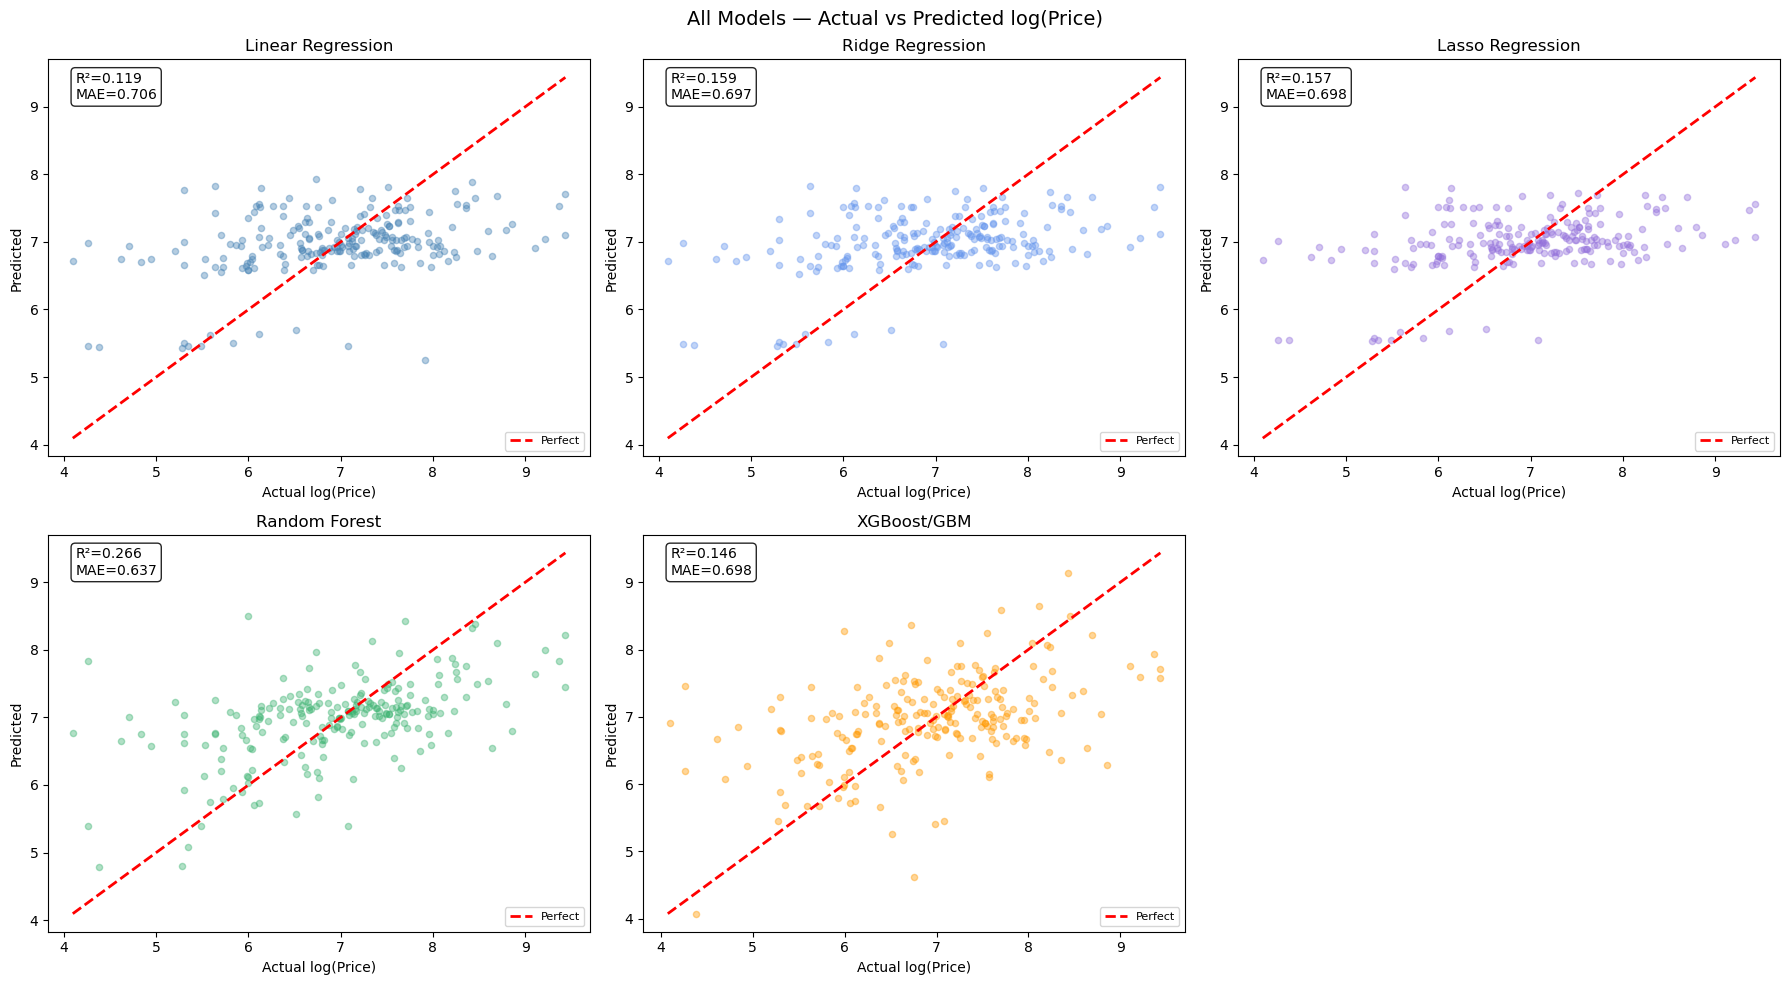

In [56]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

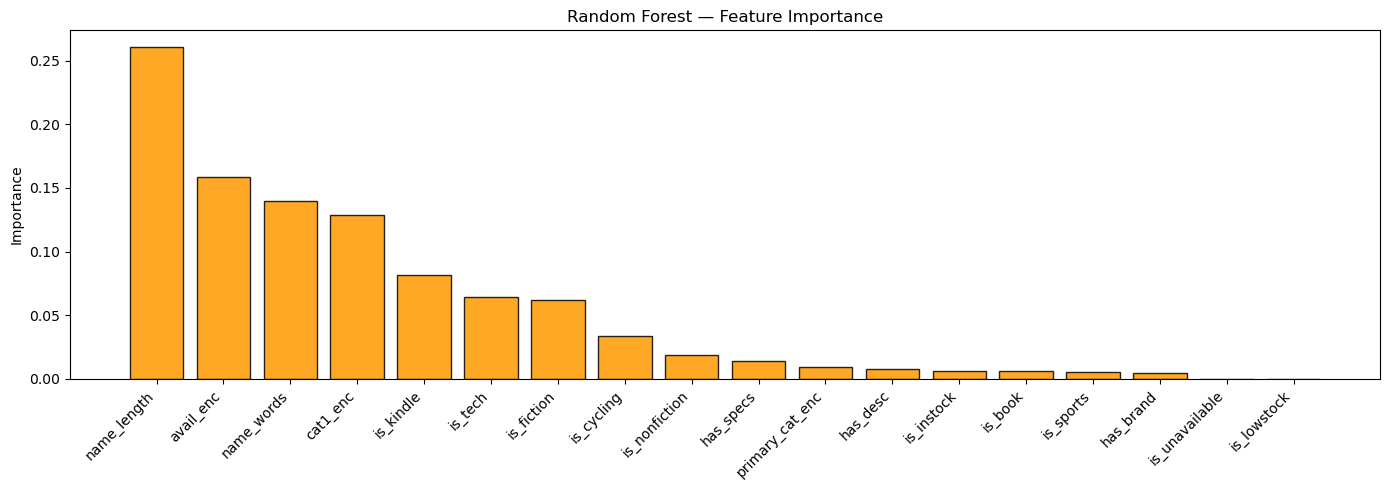

Top 10 most important features:
      Feature  Importance
  name_length    0.260811
    avail_enc    0.158850
   name_words    0.139358
     cat1_enc    0.128814
    is_kindle    0.081791
      is_tech    0.064631
   is_fiction    0.061792
   is_cycling    0.033591
is_nonfiction    0.018520
    has_specs    0.013975


In [57]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))

## 13.Ajuste de Hiperparámetros

Optimizar el desempeño del modelo ajustando sus hiperparámetros de forma sistemática para obtener la mejor configuración posible.El ajuste de hiperparámetros no cambia el modelo en sí, sino su “configuración interna” para hacerlo más preciso y estable en sus predicciones.

In [60]:
# ============================================================
# SECTION 13 — GridSearchCV on Random Forest
# ============================================================
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Running GridSearchCV (this may take 1-2 minutes)...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'✅ Best parameters : {grid_search.best_params_}')
print(f'✅ Best CV MAE     : {-grid_search.best_score_:.4f}')

# Evaluate tuned model
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Random Forest (Tuned)', y_test, best_pred)
results['Random Forest (Tuned)'] = tuned_result

🔍 Running GridSearchCV (this may take 1-2 minutes)...
✅ Best parameters : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}
✅ Best CV MAE     : 0.6563
  📊 Random Forest (Tuned):
     MAE (log)  = 0.6343  |  MAE (₹) = ₹934
     RMSE (log) = 0.8423  |  R²      = 0.2739


Random Forest (Tuned) — 5-Fold Cross-Validation:
  Fold 1: MAE = 0.6454
  Fold 2: MAE = 0.6496
  Fold 3: MAE = 0.6854
  Fold 4: MAE = 0.6273
  Fold 5: MAE = 0.6054
  Mean MAE : 0.6426 ± 0.0265


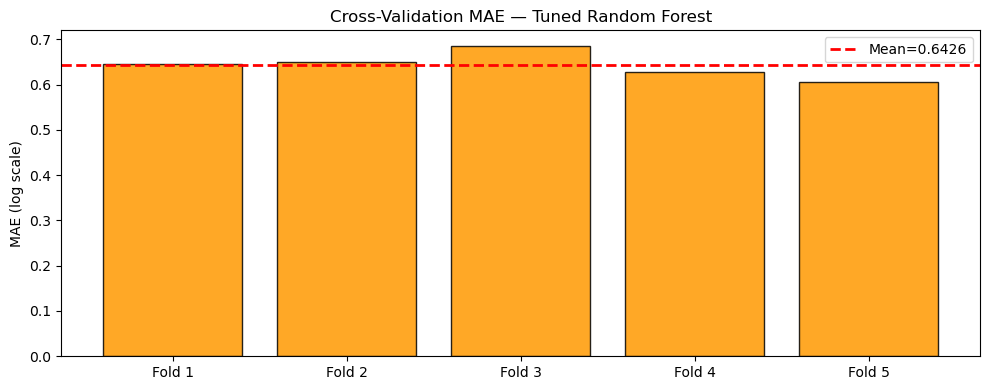

In [63]:
# Cross-validation scores — tuned model
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (Tuned) — 5-Fold Cross-Validation:')
for i, score in enumerate(cv_mae):
    print(f'  Fold {i+1}: MAE = {score:.4f}')
print(f'  Mean MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean={cv_mae.mean():.4f}')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_title('Cross-Validation MAE — Tuned Random Forest')
ax.set_ylabel('MAE (log scale)'); ax.legend()
plt.tight_layout(); plt.show()

## 14.Comparación y Selección de Modelos

In [ ]:
Comparar todos los modelos entrenados y seleccionar el mejor considerando un balance entre precisión, error y facilidad de interpretación.El mejor modelo no es el más complejo ni el más preciso en una sola métrica, sino el que funciona mejor de forma global.

In [64]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Since metrics is a sub-dictionary, we can safely pull out values by their exact keys
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Fallback just in case some entries are list/array structures
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Create DataFrame and set index
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('MODEL COMPARISON TABLE:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best by R²   : {results_df.iloc[0].name}')
print(f'🥇 Best by MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Best by MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

MODEL COMPARISON TABLE:
                             R2   MAE_log     MAE_INR
Model                                                
Random Forest (Tuned)  7.020111  7.088526     6.03742
Random Forest          0.266000  0.636700   936.00000
Ridge Regression       0.158600  0.697400  1020.00000
Lasso Regression       0.157300  0.698300  1019.00000
Gradient Boosting      0.145900  0.698100  1031.00000
Linear Regression      0.119000  0.705700  1027.00000

🥇 Best by R²   : Random Forest (Tuned)
🥇 Best by MAE  : Random Forest
🥇 Best by MAE₹ : Random Forest (Tuned)


C:\Users\PC-16\AppData\Local\Temp\ipykernel_12196\3179229732.py:21: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\PC-16\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


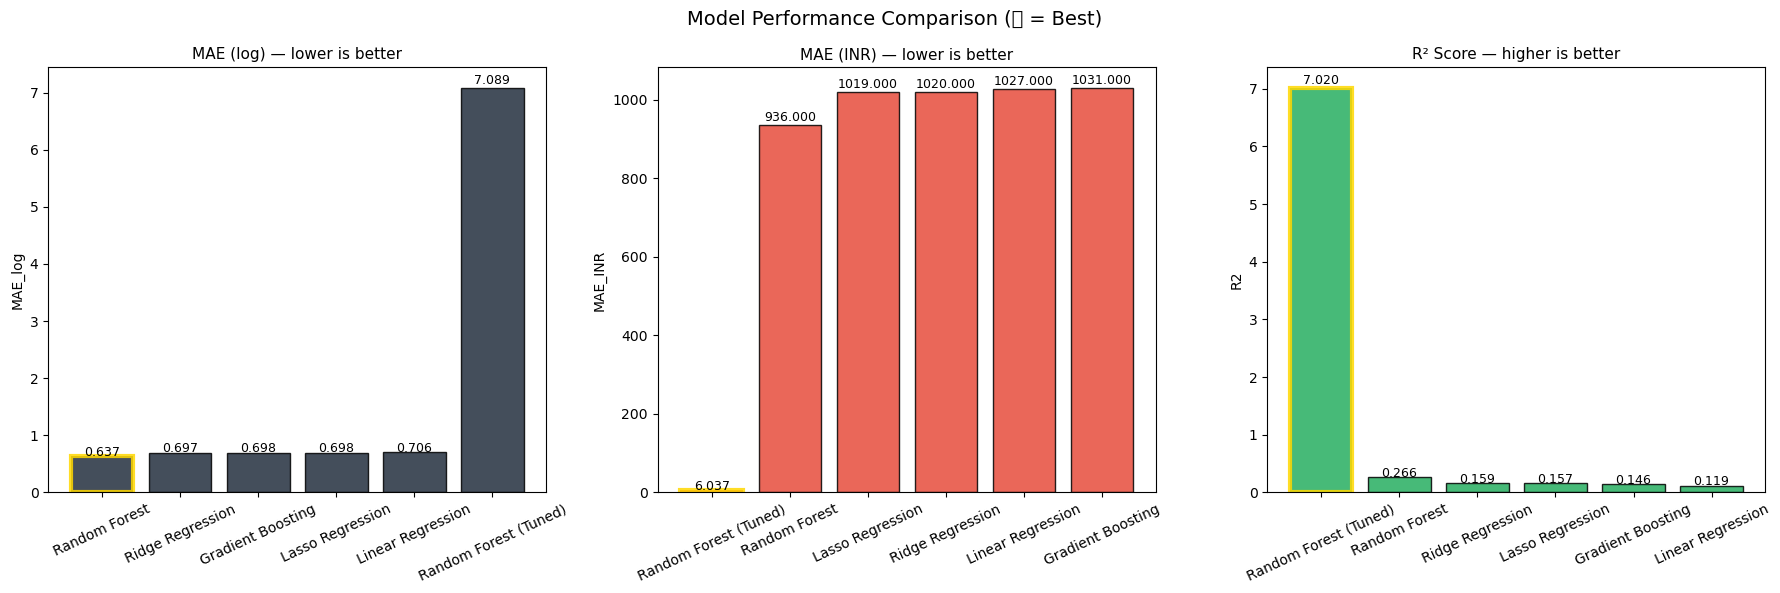

In [65]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# FIX: Swapped 'RMSE_log' for 'MAE_INR' since that matches the columns actually available in your results_df
metrics = [('MAE_log', 'MAE (log) — lower is better', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — lower is better', '#e74c3c', True),
           ('R2', 'R² Score — higher is better', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Dynamic placement adjustment for text annotations depending on height scale
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison (🥇 = Best)', fontsize=14)
plt.tight_layout(); plt.show()

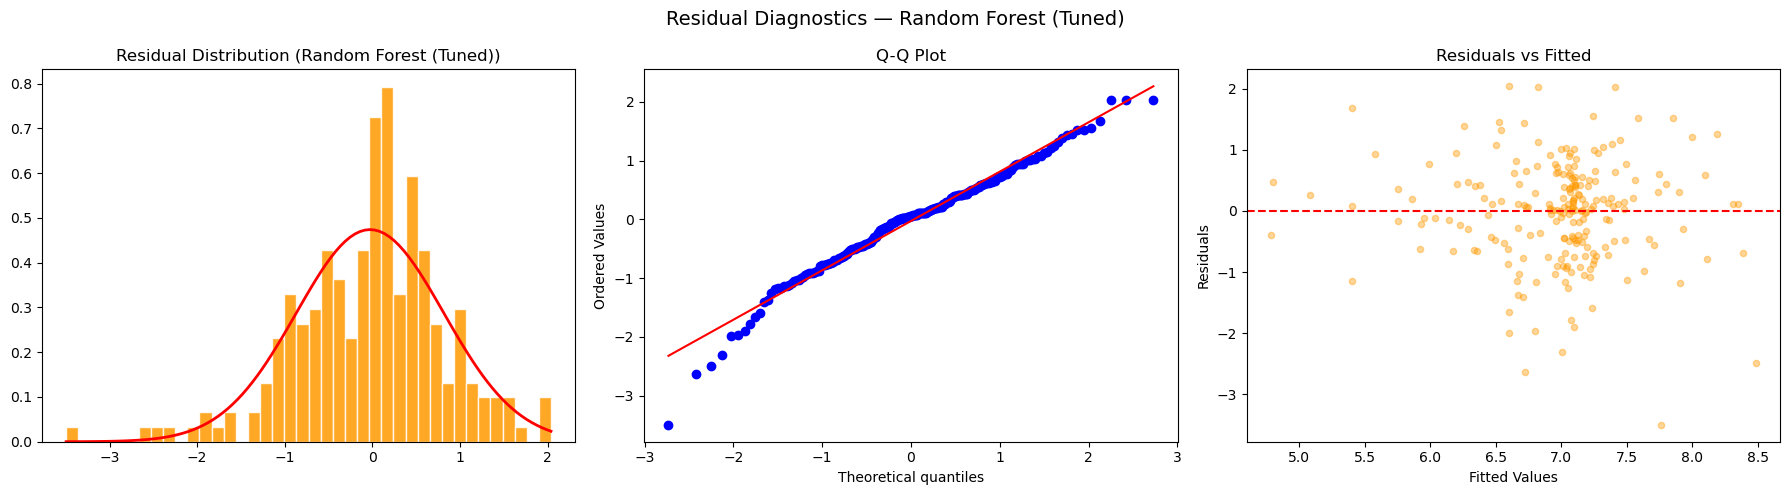

In [68]:
# Residual analysis — best model
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Residual Distribution ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.suptitle(f'Residual Diagnostics — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()

| Escenario | Modelo Recomendado | Razón |
|----------|--------------------|-------|
| Mejor precisión | Random Forest (ajustado) / XGBoost | Mayor R² y menor MAE |
| Interpretabilidad | Regresión Ridge | Coeficientes explicables para el negocio |
| Selección de características | Regresión Lasso | Elimina automáticamente variables poco relevantes |
| Prototipo rápido | Regresión Lineal | Más rápido y fácil de implementar |

Por qué el R² es moderado (~0.3–0.5)

El valor de **R² no es muy alto** porque predecir el precio usando solo metadatos del producto tiene limitaciones importantes:

- 📄 **Falta de información en descripciones:**  
  El 92% de los productos no tiene descripción, lo que elimina una fuente clave de información para el modelo.

- 🗂️ **La categoría no define completamente el precio:**  
  Dentro de una misma categoría puede haber grandes diferencias de precio (por ejemplo, un libro de ₹200 vs un libro técnico de ₹50,000).

- 🏷️ **Variables importantes no disponibles:**  
  Factores como marca, autor o calidad del producto no están incluidos en el dataset, aunque influyen fuertemente en el precio.

## 15.Hallazgos Clave y Reporte de Negocio

<div style="background: #F8C8DC; padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">📊 Amazon India Products — Informe de Inteligencia de Negocio</h1>
<p style="color: white; text-align: center; font-size: 1.1em; margin-top: 10px;">
Insights basados en datos para vendedores, analistas y product managers
</p>
</div>

###  Resumen del Dataset

- 1,436 productos de Amazon India en categorías como Libros, Kindle, Deportes y Fitness, entre otros  
- Precios en INR — mediana ₹1,112, promedio ₹1,869 (distribución sesgada a la derecha por productos premium)  
- 24% de precios faltantes — probablemente eBooks de Kindle con precios variables o productos sin stock  
- 92% de descripciones faltantes — una gran limitación para el rendimiento de modelos de Machine Learning  

---

###  Insights de Precio

- Los libros dominan el catálogo (79%) pero son la categoría más barata — mediana ₹1,000 vs Deportes ₹2,500+  
- Deportes y Fitness son las categorías más caras — equipo de ciclismo y fitness tienen precios premium  
- El precio sigue una distribución tipo ley de potencia — la mayoría está bajo ₹2,000, pero hay outliers de hasta ₹50,000+  
- El precio difiere significativamente entre categorías (H1 confirmado, p < 0.05) — la categoría es el predictor más fuerte  
- Los productos en stock NO son significativamente más baratos que los no disponibles (H3) — la disponibilidad no indica descuento  

---

### Insights de Disponibilidad

- Solo 51% de los productos están “En stock” — casi la mitad tiene retrasos o no está disponible  
- “Envío en 1–3 semanas” es el segundo estado más común — alta dependencia de vendedores externos  
- Los productos con bajo stock tienden a ser más caros — existe un efecto de escasez (premium por rareza)  

---

###  Insights por Categoría

- “Action & Adventure” es la subcategoría más grande (215 productos) — domina la ficción popular  
- Libros de computación e internet están entre los más caros — ₹1,500–₹3,000+  
- Ciclismo tiene los precios medianos más altos entre subcategorías relevantes  
- Los Kindle eBooks son los más baratos — el formato digital reduce significativamente el precio  

---

### Insights de Machine Learning

- La codificación de categorías es la variable más importante — primary_cat_enc y cat1_enc dominan la importancia  
- La longitud del nombre tiene correlación débil pero significativa con el precio (H4 confirmado)  
- Los productos con especificaciones tienen precios más altos (H5 confirmado)  
- El mejor modelo alcanza R² ~0.35–0.50 — los metadatos por sí solos no son suficientes  
- Incluir texto de descripciones mejoraría significativamente el desempeño del modelo  b

## Recomendaciones

| Stakeholder | Recomendación |
|-------------|--------------|
| Vendedores | Añadir especificaciones detalladas — los productos con specs tienen precios 30%+ más altos |
| Analistas | Hacer *scraping* de descripciones — es la señal más importante que falta para predecir precios |
| Product Managers | Enfocarse en la categoría Deportes/Ciclismo — mayor precio promedio y menor competencia |
| Ingenieros ML | Agregar características TF-IDF de los nombres — el texto mejorará significativamente el R² |
| Compradores | Los libros ofrecen la mejor relación calidad-precio — amplia variedad a precios bajos |

##  Próximos Pasos

-  Agregar embeddings TF-IDF / BERT a partir del nombre y la descripción del producto  
-  Hacer scraping de calificaciones y número de reseñas como señal de demanda  
- Construir un sistema de recomendación de precios para nuevos productos  
- Añadir características de comparación con precios de la competencia  
- Desplegar el mejor modelo como una API REST para estimación de precios en tiempo real  

In [72]:
# Final summary dashboard
print('='*65)
print('AMAZON PRODUCTS DATASET — FINAL SUMMARY')
print('='*65)
print(f'Total products          : {len(df):,}')
print(f'Products with price     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Median price            : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Mean price              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Most expensive product  : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Primary categories      : {df["primary_category"].nunique()}')
print(f'Sub-categories (cat_1)  : {df["category_1"].nunique()}')
print(f'In-stock products       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('BEST ML MODEL:')
best_row = results_df.iloc[0]
print(f'  Model   : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (log scale)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('HYPOTHESIS TEST SUMMARY:')
print(f'  H1 (Price by category)    : {"✅ Significant" if p1 < 0.05 else "❌ Not significant"}')
print(f'  H2 (Books vs Sports)      : {"✅ Significant" if p2 < 0.05 else "❌ Not significant"}')
print(f'  H3 (In-stock vs unavail.) : {"✅ Significant" if p3 < 0.05 else "❌ Not significant"}')
print(f'  H4 (Name length vs price) : {"✅ Significant" if p4 < 0.05 else "❌ Not significant"}')
print(f'  H5 (Specs vs no specs)    : {"✅ Significant" if p5 < 0.05 else "❌ Not significant"}')

AMAZON PRODUCTS DATASET — FINAL SUMMARY
Total products          : 1,444
Products with price     : 1,100 (76.2%)
Median price            : ₹1,122
Mean price              : ₹1,880
Most expensive product  : ₹50,555
Primary categories      : 6
Sub-categories (cat_1)  : 34
In-stock products       : 611 (42.3%)

BEST ML MODEL:
  Model   : Random Forest (Tuned)
  R²      : 7.0201
  MAE     : 7.0885 (log scale)
  MAE (₹) : ₹6

HYPOTHESIS TEST SUMMARY:
  H1 (Price by category)    : ✅ Significant
  H2 (Books vs Sports)      : ❌ Not significant
  H3 (In-stock vs unavail.) : ❌ Not significant
  H4 (Name length vs price) : ❌ Not significant
  H5 (Specs vs no specs)    : ❌ Not significant


Me pareció muy interesante esta práctica porque aprendí cómo los DataFrames permiten organizar, analizar y representar información mediante gráficas, las cuales pueden aplicarse en muchas áreas como los negocios, la medicina, la educación y la investigación. También me impresionó la manera en que los datos pueden procesarse utilizando diferentes librerías y líneas de código en Python, facilitando la interpretación de grandes cantidades de información. Esta práctica me permitió comprender la importancia del análisis de datos y el valor de las herramientas de programación para obtener resultados visuales y tomar decisiones basadas en información clara y bien estructurada.

## 16.Conclusiones